In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

DATA = '../data/ml-latest-small/ml-latest-small/'
movies  = pd.read_csv(DATA + 'movies.csv')
ratings = pd.read_csv(DATA + 'ratings.csv')

# explode genres so each row = one movie-genre pair
movies_exploded = movies.copy()
movies_exploded['genres'] = movies_exploded['genres'].str.split('|')
movies_exploded = movies_exploded.explode('genres')
movies_exploded = movies_exploded[movies_exploded['genres'] != '(no genres listed)']

print(f'Movies: {len(movies)}  |  Ratings: {len(ratings)}  |  Unique genres: {movies_exploded.genres.nunique()}')

Movies: 9742  |  Ratings: 100836  |  Unique genres: 19


## 1. Number of movies per genre

C:\Users\anshu\AppData\Local\Temp\ipykernel_19268\2348566096.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, ax=ax, palette='viridis')


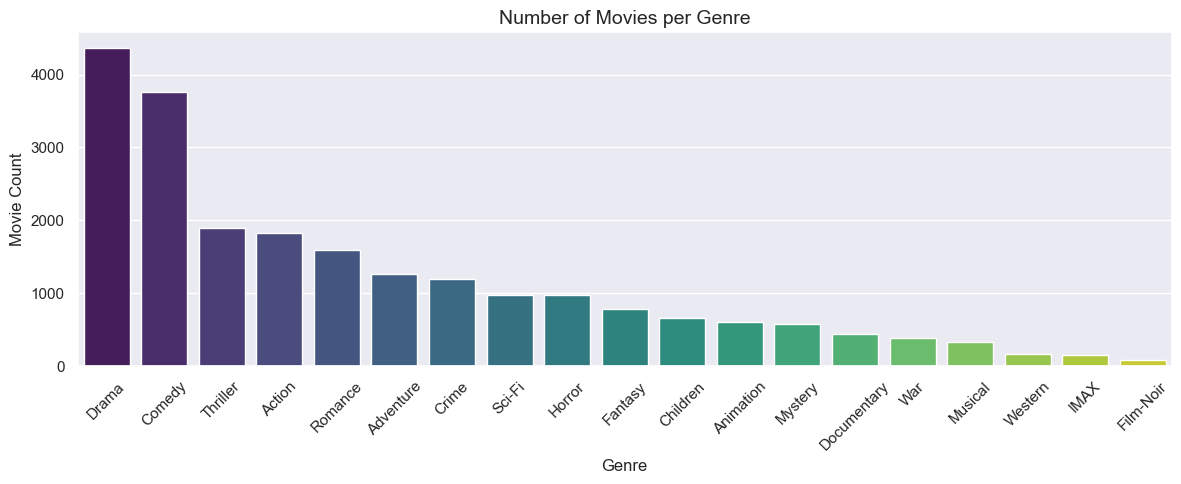

genres
Drama          4361
Comedy         3756
Thriller       1894
Action         1828
Romance        1596
Adventure      1263
Crime          1199
Sci-Fi          980
Horror          978
Fantasy         779
Children        664
Animation       611
Mystery         573
Documentary     440
War             382
Musical         334
Western         167
IMAX            158
Film-Noir        87
Name: movieId, dtype: int64


In [8]:
genre_counts = movies_exploded.groupby('genres')['movieId'].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=genre_counts.index, y=genre_counts.values, ax=ax, palette='viridis')
ax.set_title('Number of Movies per Genre', fontsize=14)
ax.set_xlabel('Genre')
ax.set_ylabel('Movie Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print(genre_counts)

## 2. Number of ratings per genre

C:\Users\anshu\AppData\Local\Temp\ipykernel_19268\3865791169.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, ax=ax, palette='magma')


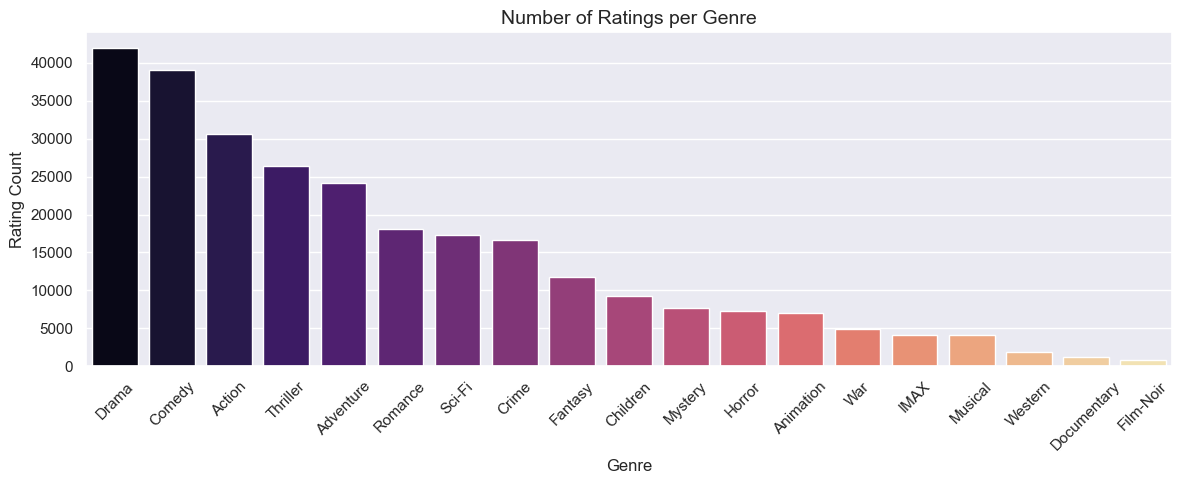

In [3]:
merged = ratings.merge(movies_exploded[['movieId','genres']], on='movieId')
rating_counts = merged.groupby('genres')['rating'].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, ax=ax, palette='magma')
ax.set_title('Number of Ratings per Genre', fontsize=14)
ax.set_xlabel('Genre')
ax.set_ylabel('Rating Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 3. Average rating per genre

C:\Users\anshu\AppData\Local\Temp\ipykernel_19268\3369681359.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=avg_rating.index, y=avg_rating.values, ax=ax, palette='coolwarm')


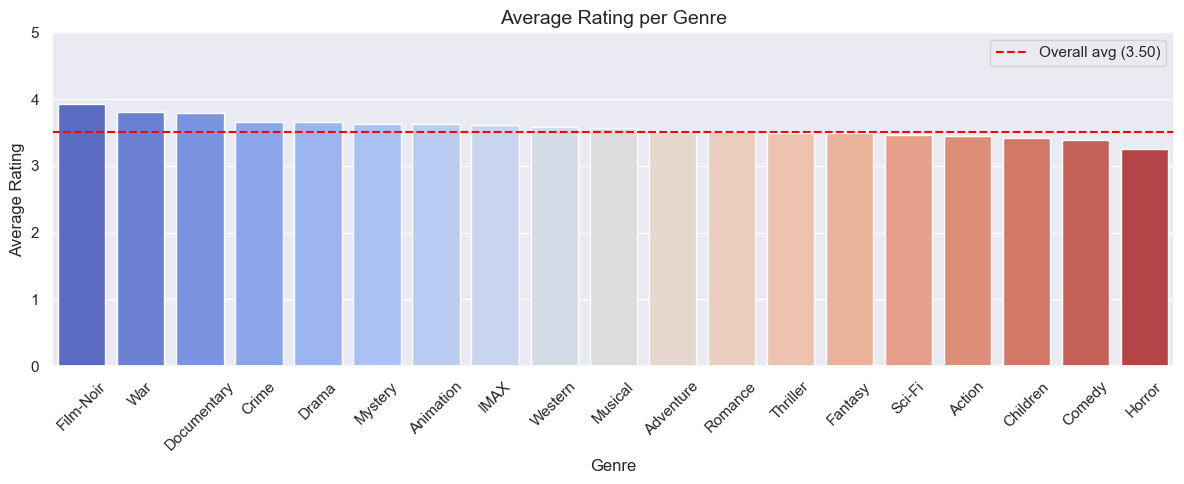

genres
Film-Noir      3.920
War            3.808
Documentary    3.798
Crime          3.658
Drama          3.656
Mystery        3.632
Animation      3.630
IMAX           3.618
Western        3.584
Musical        3.564
Adventure      3.509
Romance        3.507
Thriller       3.494
Fantasy        3.491
Sci-Fi         3.456
Action         3.448
Children       3.413
Comedy         3.385
Horror         3.258
Name: rating, dtype: float64


In [4]:
avg_rating = merged.groupby('genres')['rating'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = sns.barplot(x=avg_rating.index, y=avg_rating.values, ax=ax, palette='coolwarm')
ax.set_title('Average Rating per Genre', fontsize=14)
ax.set_xlabel('Genre')
ax.set_ylabel('Average Rating')
ax.set_ylim(0, 5)
ax.axhline(ratings['rating'].mean(), color='red', linestyle='--', label=f'Overall avg ({ratings.rating.mean():.2f})')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print(avg_rating.round(3))

## 4. Rating distribution per genre (box plot)

C:\Users\anshu\AppData\Local\Temp\ipykernel_19268\3242082739.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x='genres', y='rating', order=order, ax=ax, palette='Set3')


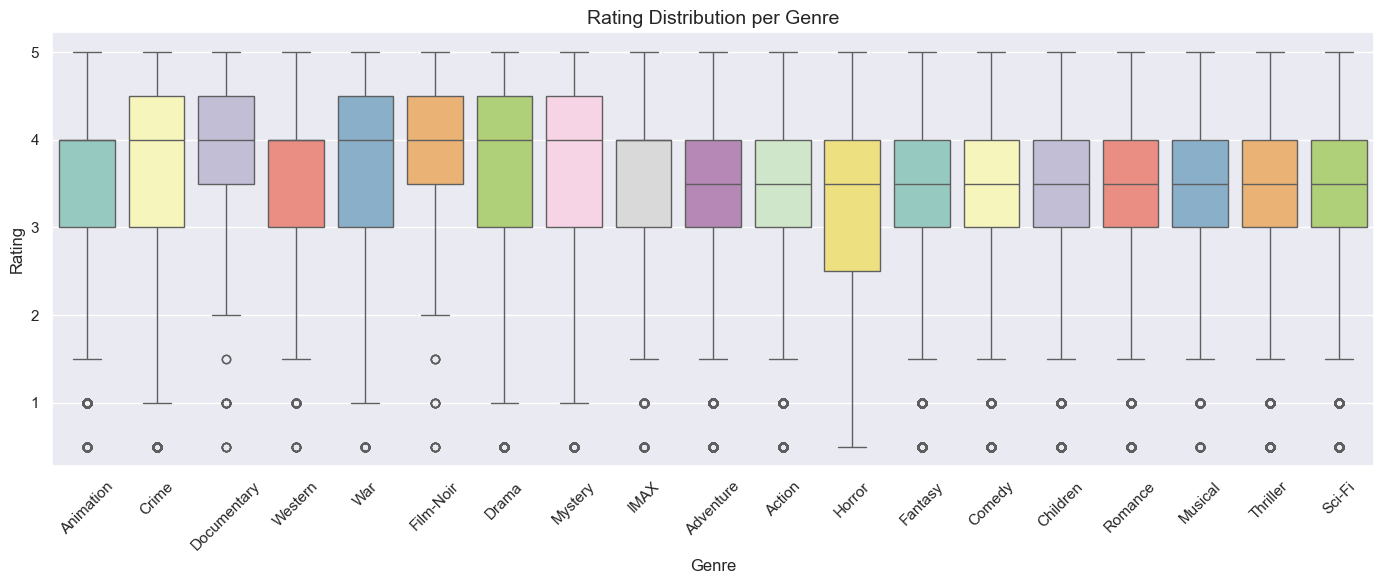

In [5]:
order = merged.groupby('genres')['rating'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=merged, x='genres', y='rating', order=order, ax=ax, palette='Set3')
ax.set_title('Rating Distribution per Genre', fontsize=14)
ax.set_xlabel('Genre')
ax.set_ylabel('Rating')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Genre popularity bias — avg rating × log(rating count)

C:\Users\anshu\AppData\Local\Temp\ipykernel_19268\3681624909.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_stats, x='genre', y='popularity_bias', ax=ax, palette='rocket')


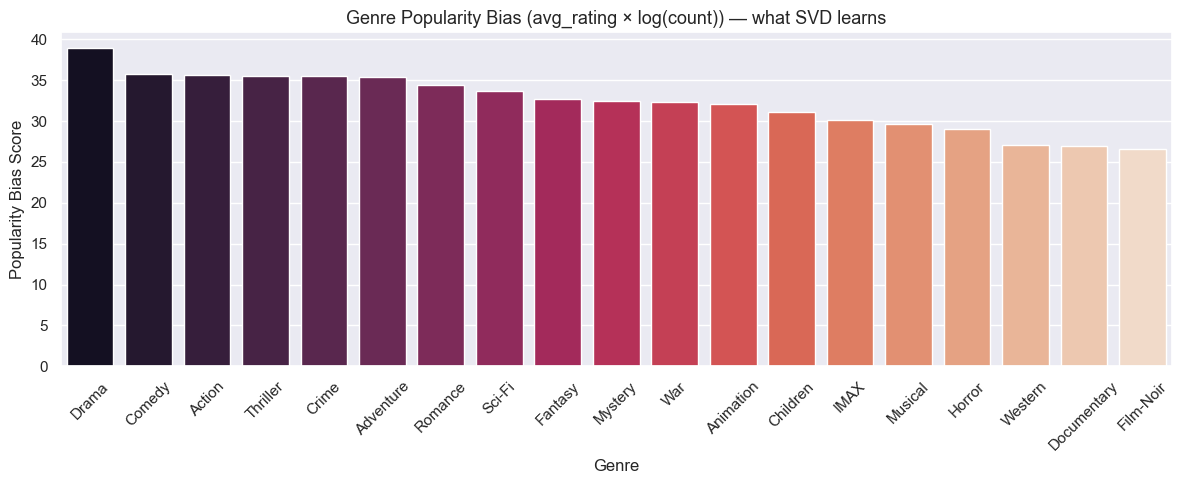

      genre  avg_rating  rating_count  popularity_bias
      Drama    3.656184         41928        38.915451
     Comedy    3.384721         39053        35.785639
     Action    3.447984         30635        35.617440
   Thriller    3.493706         26452        35.576840
      Crime    3.658294         16681        35.566246
  Adventure    3.508609         24161        35.410763
    Romance    3.506511         18124        34.381504
     Sci-Fi    3.455721         17243        33.711319
    Fantasy    3.491001         11834        32.741453
    Mystery    3.632460          7674        32.494985
        War    3.808294          4859        32.327821
  Animation    3.629937          6988        32.132539
   Children    3.412956          9208        31.153247
       IMAX    3.618335          4145        30.140369
    Musical    3.563678          4138        29.679058
     Horror    3.258195          7291        28.980124
    Western    3.583938          1930        27.115333
Documentar

In [6]:
import numpy as np

genre_stats = merged.groupby('genres')['rating'].agg(['mean','count']).reset_index()
genre_stats.columns = ['genre', 'avg_rating', 'rating_count']
genre_stats['popularity_bias'] = genre_stats['avg_rating'] * np.log1p(genre_stats['rating_count'])
genre_stats = genre_stats.sort_values('popularity_bias', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=genre_stats, x='genre', y='popularity_bias', ax=ax, palette='rocket')
ax.set_title('Genre Popularity Bias (avg_rating × log(count)) — what SVD learns', fontsize=13)
ax.set_xlabel('Genre')
ax.set_ylabel('Popularity Bias Score')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print(genre_stats[['genre','avg_rating','rating_count','popularity_bias']].to_string(index=False))

## 6. Genre co-occurrence heatmap (which genres appear together)

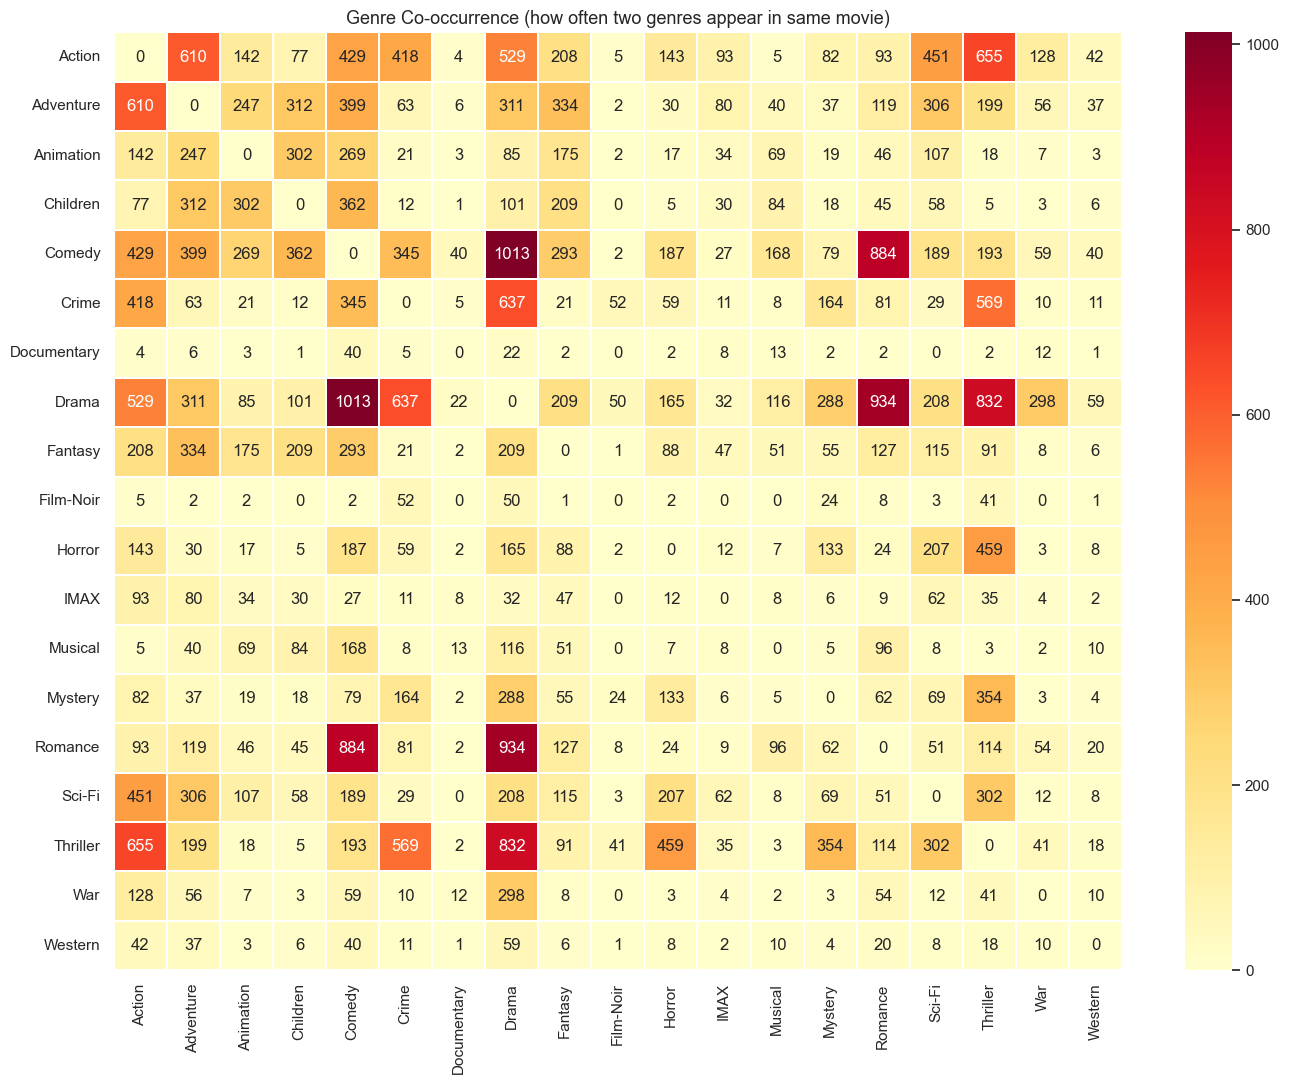

In [7]:
from itertools import combinations

genres_list = movies['genres'].str.split('|').tolist()
all_genres = sorted(movies_exploded['genres'].unique())
comat = pd.DataFrame(0, index=all_genres, columns=all_genres)

for g_list in genres_list:
    g_list = [g for g in g_list if g != '(no genres listed)']
    for g1, g2 in combinations(g_list, 2):
        comat.loc[g1, g2] += 1
        comat.loc[g2, g1] += 1

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(comat, ax=ax, cmap='YlOrRd', fmt='d', annot=True, linewidths=0.3)
ax.set_title('Genre Co-occurrence (how often two genres appear in same movie)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Overall Data Overview

In [9]:
# Load additional data
tags = pd.read_csv(DATA + 'tags.csv')
links = pd.read_csv(DATA + 'links.csv')

print("=== DATA OVERVIEW ===")
print(f"Users: {ratings['userId'].nunique()}")
print(f"Movies: {movies['movieId'].nunique()}")
print(f"Ratings: {len(ratings)}")
print(f"Tags: {len(tags)}")
print(f"Links: {len(links)}")
print(f"\nRating scale: {ratings['rating'].min()} to {ratings['rating'].max()}")
print(f"Average rating: {ratings['rating'].mean():.2f}")
print(f"Median rating: {ratings['rating'].median()}")
print(f"Most common rating: {ratings['rating'].mode().iloc[0]}")

=== DATA OVERVIEW ===
Users: 610
Movies: 9742
Ratings: 100836
Tags: 3683
Links: 9742

Rating scale: 0.5 to 5.0
Average rating: 3.50
Median rating: 3.5
Most common rating: 4.0


## 8. Rating Distribution

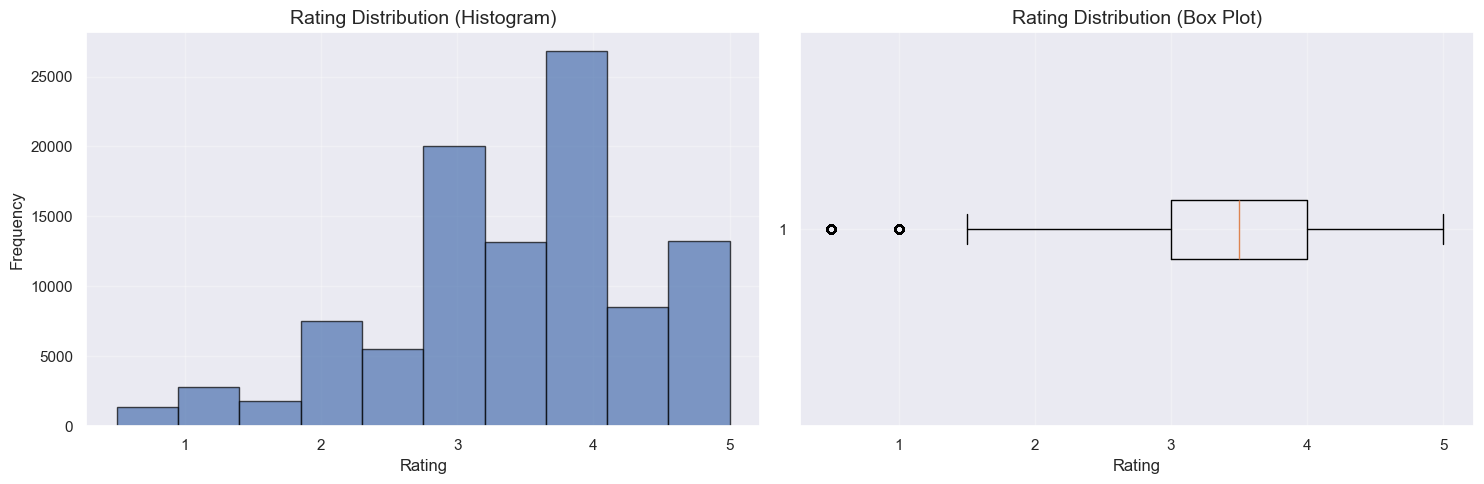

Rating value counts:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
ax1.hist(ratings['rating'], bins=10, edgecolor='black', alpha=0.7)
ax1.set_title('Rating Distribution (Histogram)', fontsize=14)
ax1.set_xlabel('Rating')
ax1.set_ylabel('Frequency')
ax1.grid(True, alpha=0.3)

# Box plot
ax2.boxplot(ratings['rating'], vert=False)
ax2.set_title('Rating Distribution (Box Plot)', fontsize=14)
ax2.set_xlabel('Rating')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Rating value counts:")
print(ratings['rating'].value_counts().sort_index())

## 9. User Activity Analysis

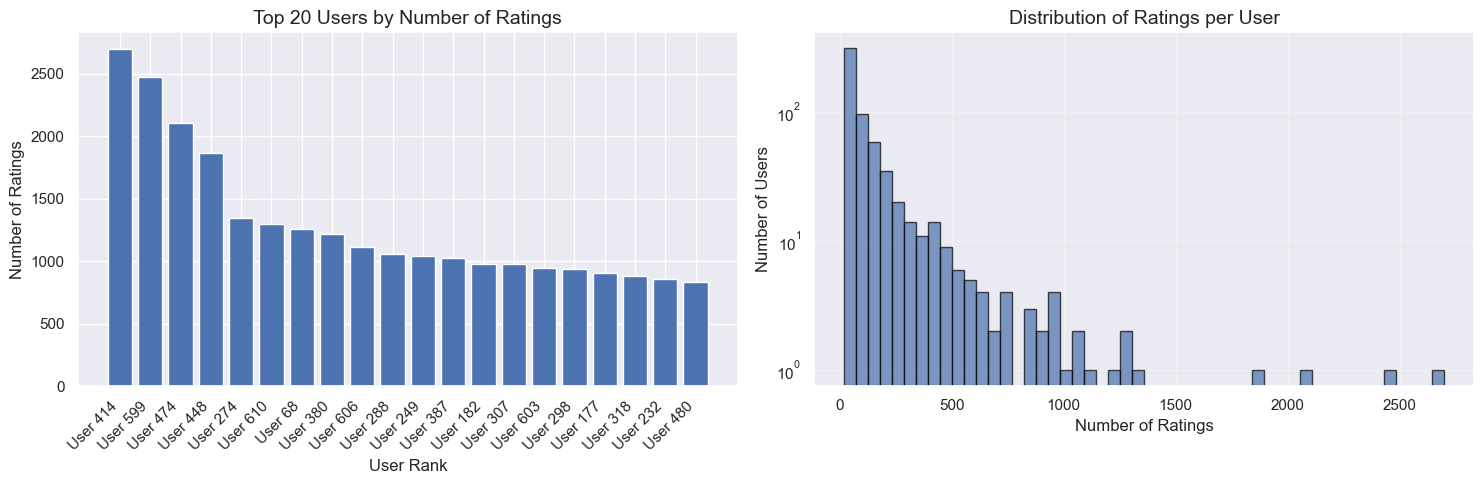

Average ratings per user: 165.3
Median ratings per user: 70.5
Max ratings per user: 2698
Min ratings per user: 20


In [11]:
user_ratings_count = ratings.groupby('userId')['rating'].count().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Top 20 users by rating count
top_users = user_ratings_count.head(20)
ax1.bar(range(len(top_users)), top_users.values)
ax1.set_title('Top 20 Users by Number of Ratings', fontsize=14)
ax1.set_xlabel('User Rank')
ax1.set_ylabel('Number of Ratings')
ax1.set_xticks(range(len(top_users)))
ax1.set_xticklabels([f'User {uid}' for uid in top_users.index], rotation=45, ha='right')

# Distribution of ratings per user
ax2.hist(user_ratings_count, bins=50, edgecolor='black', alpha=0.7)
ax2.set_title('Distribution of Ratings per User', fontsize=14)
ax2.set_xlabel('Number of Ratings')
ax2.set_ylabel('Number of Users')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average ratings per user: {user_ratings_count.mean():.1f}")
print(f"Median ratings per user: {user_ratings_count.median()}")
print(f"Max ratings per user: {user_ratings_count.max()}")
print(f"Min ratings per user: {user_ratings_count.min()}")

## 10. Movie Popularity Analysis

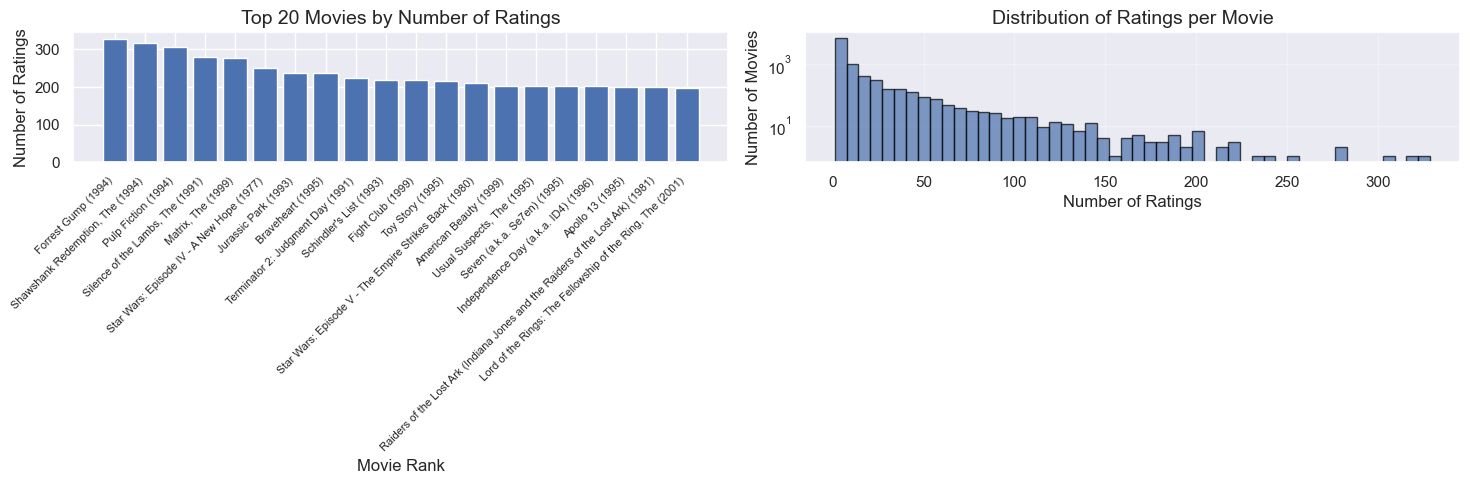

Average ratings per movie: 10.4
Median ratings per movie: 3.0
Max ratings per movie: 329
Min ratings per movie: 1
Movies with only 1 rating: 3446 (35.4%)


In [12]:
movie_ratings_count = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Top 20 movies by rating count
top_movies = movie_ratings_count.head(20)
movie_titles = movies.set_index('movieId')['title'].loc[top_movies.index]
ax1.bar(range(len(top_movies)), top_movies.values)
ax1.set_title('Top 20 Movies by Number of Ratings', fontsize=14)
ax1.set_xlabel('Movie Rank')
ax1.set_ylabel('Number of Ratings')
ax1.set_xticks(range(len(top_movies)))
ax1.set_xticklabels(movie_titles, rotation=45, ha='right', fontsize=8)

# Distribution of ratings per movie
ax2.hist(movie_ratings_count, bins=50, edgecolor='black', alpha=0.7)
ax2.set_title('Distribution of Ratings per Movie', fontsize=14)
ax2.set_xlabel('Number of Ratings')
ax2.set_ylabel('Number of Movies')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average ratings per movie: {movie_ratings_count.mean():.1f}")
print(f"Median ratings per movie: {movie_ratings_count.median()}")
print(f"Max ratings per movie: {movie_ratings_count.max()}")
print(f"Min ratings per movie: {movie_ratings_count.min()}")

# Movies with only 1 rating
single_rating_movies = (movie_ratings_count == 1).sum()
print(f"Movies with only 1 rating: {single_rating_movies} ({single_rating_movies/len(movie_ratings_count)*100:.1f}%)")

## 11. Temporal Analysis

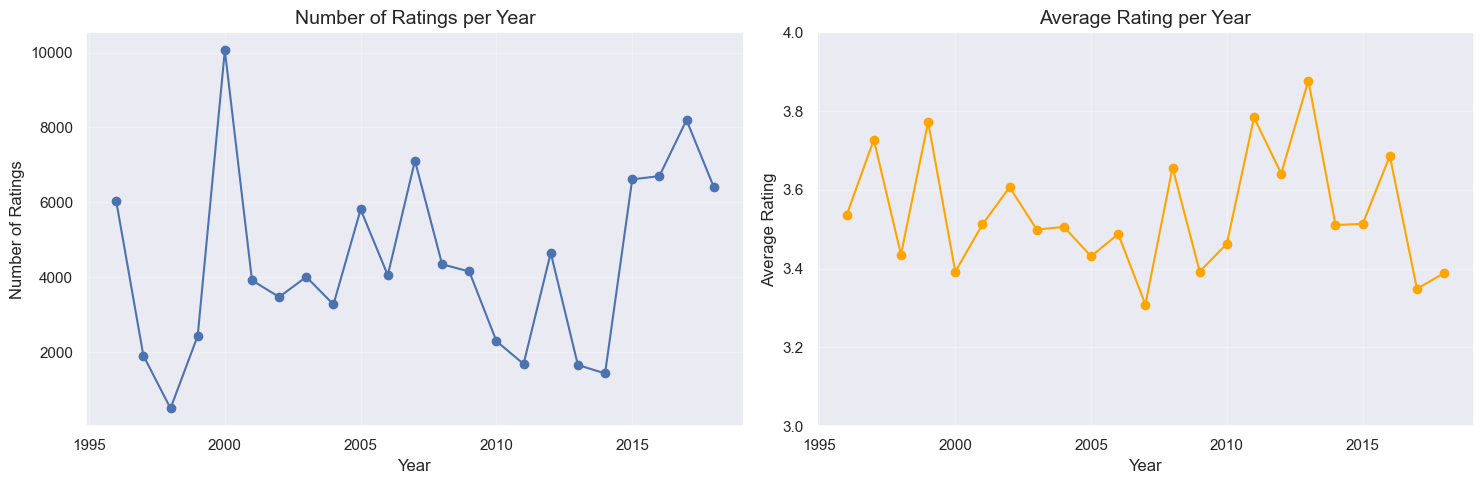

Data spans from 1996 to 2018
Total years: 23


In [13]:
import datetime

# Convert timestamp to datetime
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['timestamp'].dt.year
ratings['month'] = ratings['timestamp'].dt.month

# Ratings over years
yearly_ratings = ratings.groupby('year')['rating'].count()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Ratings per year
ax1.plot(yearly_ratings.index, yearly_ratings.values, marker='o')
ax1.set_title('Number of Ratings per Year', fontsize=14)
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Ratings')
ax1.grid(True, alpha=0.3)

# Average rating per year
yearly_avg = ratings.groupby('year')['rating'].mean()
ax2.plot(yearly_avg.index, yearly_avg.values, marker='o', color='orange')
ax2.set_title('Average Rating per Year', fontsize=14)
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Rating')
ax2.set_ylim(3, 4)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Data spans from {ratings['timestamp'].min().year} to {ratings['timestamp'].max().year}")
print(f"Total years: {ratings['year'].nunique()}")

## 12. Tags Analysis

=== TAGS ANALYSIS ===
Total tags: 3683
Unique tags: 1589
Users who tagged: 58
Movies tagged: 1572


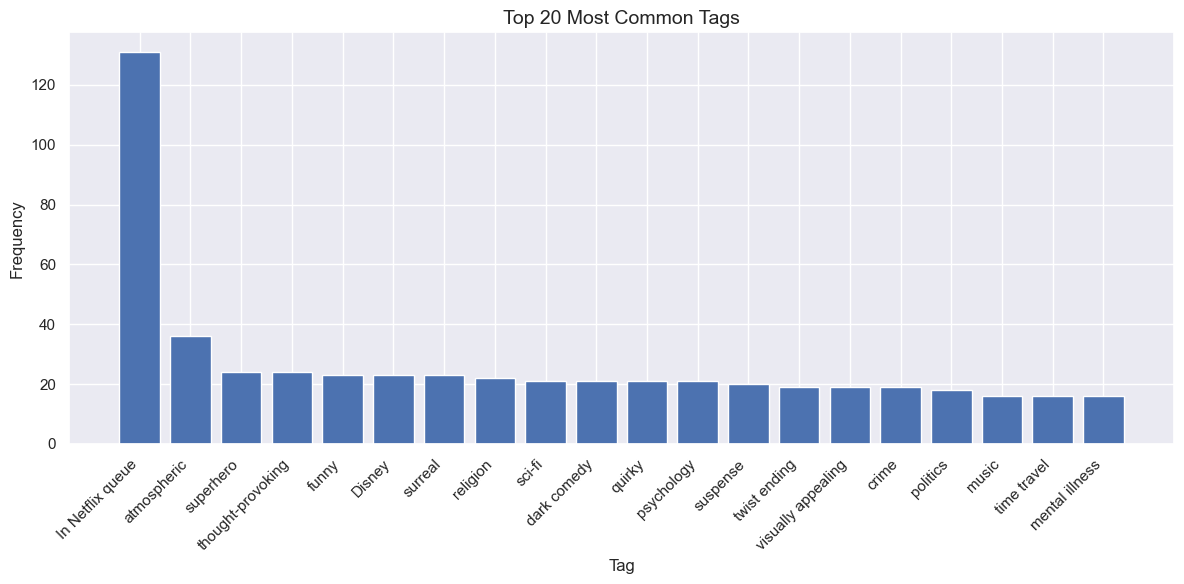

Top 10 tags:
tag
In Netflix queue     131
atmospheric           36
superhero             24
thought-provoking     24
funny                 23
Disney                23
surreal               23
religion              22
sci-fi                21
dark comedy           21
Name: count, dtype: int64


In [14]:
# Tags analysis
tags['timestamp'] = pd.to_datetime(tags['timestamp'], unit='s')

print("=== TAGS ANALYSIS ===")
print(f"Total tags: {len(tags)}")
print(f"Unique tags: {tags['tag'].nunique()}")
print(f"Users who tagged: {tags['userId'].nunique()}")
print(f"Movies tagged: {tags['movieId'].nunique()}")

# Most common tags
top_tags = tags['tag'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(top_tags)), top_tags.values)
ax.set_title('Top 20 Most Common Tags', fontsize=14)
ax.set_xlabel('Tag')
ax.set_ylabel('Frequency')
ax.set_xticks(range(len(top_tags)))
ax.set_xticklabels(top_tags.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 tags:")
print(top_tags.head(10))